In [1]:
#Import necessary packages
import os, json, itertools
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

plt.rcParams.update({'figure.dpi': 120})
Path('figures').mkdir(exist_ok=True); Path('artifacts').mkdir(exist_ok=True)

In [2]:
#Data collection
provenance = {"data_source": "Kaggle — Austin Animal Center shelter intakes & outcomes (public copy)",
              "local_file": "aac_intakes_outcomes.csv"}
with open('artifacts/data_provenance.json', 'w') as f:
    json.dump(provenance, f, indent=2)

#Load data
df = pd.read_csv('aac_intakes_outcomes.csv', keep_default_na=False)
print('Raw shape:', df.shape)
df.head()

Raw shape: (79672, 41)


,age_upon_outcome,animal_id_outcome,date_of_birth,outcome_subtype,outcome_type,sex_upon_outcome,age_upon_outcome_(days),age_upon_outcome_(years),age_upon_outcome_age_group,outcome_datetime,...,age_upon_intake_age_group,intake_datetime,intake_month,intake_year,intake_monthyear,intake_weekday,intake_hour,intake_number,time_in_shelter,time_in_shelter_days
0,10 years,A006100,2007-07-09 00:00:00,,Return to Owner,Neutered Male,3650,10.0,"(7.5, 10.0]",2017-12-07 14:07:00,...,"(7.5, 10.0]",2017-12-07 00:00:00,12,2017,2017-12,Thursday,14,1.0,0 days 14:07:00.000000000,0.588194
1,7 years,A006100,2007-07-09 00:00:00,,Return to Owner,Neutered Male,2555,7.0,"(5.0, 7.5]",2014-12-20 16:35:00,...,"(5.0, 7.5]",2014-12-19 10:21:00,12,2014,2014-12,Friday,10,2.0,1 days 06:14:00.000000000,1.259722
2,6 years,A006100,2007-07-09 00:00:00,,Return to Owner,Neutered Male,2190,6.0,"(5.0, 7.5]",2014-03-08 17:10:00,...,"(5.0, 7.5]",2014-03-07 14:26:00,3,2014,2014-03,Friday,14,3.0,1 days 02:44:00.000000000,1.113889
3,10 years,A047759,2004-04-02 00:00:00,Partner,Transfer,Neutered Male,3650,10.0,"(7.5, 10.0]",2014-04-07 15:12:00,...,"(7.5, 10.0]",2014-04-02 15:55:00,4,2014,2014-04,Wednesday,15,1.0,4 days 23:17:00.000000000,4.970139
4,16 years,A134067,1997-10-16 00:00:00,,Return to Owner,Neutered Male,5840,16.0,"(15.0, 17.5]",2013-11-16 11:54:00,...,"(15.0, 17.5]",2013-11-16 09:02:00,11,2013,2013-11,Saturday,9,1.0,0 days 02:52:00.000000000,0.119444


In [3]:
#Extraction & Preparation: Step 1
#Normalize column names and filter to cats.

def norm(cols):
    return [c.strip().lower().replace(' ', '_').replace('/', '_').replace('-', '_') for c in cols]

df.columns = norm(df.columns)
print('Columns (first 30):', list(df.columns)[:30])

if 'animal_type' not in df.columns:
    raise KeyError("Expected 'animal_type' after normalization. Inspect your CSV headers.")
df = df[df['animal_type'].str.lower() == 'cat'].copy()
print('Cats-only shape:', df.shape)
df.head(3)

Columns (first 30): ['age_upon_outcome', 'animal_id_outcome', 'date_of_birth', 'outcome_subtype', 'outcome_type', 'sex_upon_outcome', 'age_upon_outcome_(days)', 'age_upon_outcome_(years)', 'age_upon_outcome_age_group', 'outcome_datetime', 'outcome_month', 'outcome_year', 'outcome_monthyear', 'outcome_weekday', 'outcome_hour', 'outcome_number', 'dob_year', 'dob_month', 'dob_monthyear', 'age_upon_intake', 'animal_id_intake', 'animal_type', 'breed', 'color', 'found_location', 'intake_condition', 'intake_type', 'sex_upon_intake', 'count', 'age_upon_intake_(days)']
Cats-only shape: (29539, 41)


,age_upon_outcome,animal_id_outcome,date_of_birth,outcome_subtype,outcome_type,sex_upon_outcome,age_upon_outcome_(days),age_upon_outcome_(years),age_upon_outcome_age_group,outcome_datetime,...,age_upon_intake_age_group,intake_datetime,intake_month,intake_year,intake_monthyear,intake_weekday,intake_hour,intake_number,time_in_shelter,time_in_shelter_days
10,16 years,A191351,1999-08-21 00:00:00,,Return to Owner,Intact Female,5840,16.0,"(15.0, 17.5]",2015-11-17 13:29:00,...,"(15.0, 17.5]",2015-11-13 15:57:00,11,2015,2015-11,Friday,15,1.0,3 days 21:32:00.000000000,3.897222
11,14 years,A197810,2000-01-21 00:00:00,Partner,Transfer,Spayed Female,5110,14.0,"(12.5, 15.0]",2014-12-22 15:23:00,...,"(12.5, 15.0]",2014-12-08 12:30:00,12,2014,2014-12,Monday,12,1.0,14 days 02:53:00.000000000,14.120139
16,19 years,A214991,1994-03-01 00:00:00,Suffering,Euthanasia,Spayed Female,6935,19.0,"(17.5, 20.0]",2013-12-14 13:28:00,...,"(17.5, 20.0]",2013-12-14 11:51:00,12,2013,2013-12,Saturday,11,1.0,0 days 01:37:00.000000000,0.067361


In [4]:
#Extraction & Preparation: Step 2
#Parse intake/outcome timestamps and compute Length of Stay (LOS).

import numpy as np

def first_existing(dframe, candidates):
    for c in candidates:
        if c in dframe.columns:
            return c
    return None

intake_col = first_existing(df, ['intake_datetime','datetime','intake_date'])
outcome_col = first_existing(df, ['outcome_datetime','outcome_date'])

if intake_col:
    df[intake_col] = pd.to_datetime(df[intake_col].replace({'': np.nan}), errors='coerce')
if outcome_col:
    df[outcome_col] = pd.to_datetime(df[outcome_col].replace({'': np.nan}), errors='coerce')

df['length_of_stay_days'] = np.nan
if intake_col and outcome_col:
    df['length_of_stay_days'] = (df[outcome_col] - df[intake_col]).dt.days

df[[intake_col, outcome_col, 'length_of_stay_days']].head(5)

,intake_datetime,outcome_datetime,length_of_stay_days
10,2015-11-13 15:57:00,2015-11-17 13:29:00,3
11,2014-12-08 12:30:00,2014-12-22 15:23:00,14
16,2013-12-14 11:51:00,2013-12-14 13:28:00,0
26,2013-12-27 12:13:00,2013-12-27 17:02:00,0
29,2013-12-31 16:26:00,2014-01-05 11:45:00,4


In [5]:
#Extraction & Preparation: Step 3
#Parse age text (e.g., '2 years', '3 months') into days; create age groups.

def parse_age_to_days(text):
    if pd.isna(text) or text == '':
        return np.nan
    s = str(text).lower().split()
    if not s:
        return np.nan
    try:
        n = float(s[0])
    except Exception:
        return np.nan
    joined = ' '.join(s)
    if 'year' in joined: return n * 365
    if 'month' in joined: return n * 30
    if 'week' in joined: return n * 7
    if 'day' in joined: return n
    return np.nan

age_col = 'age_upon_intake' if 'age_upon_intake' in df.columns else ('age_upon_outcome' if 'age_upon_outcome' in df.columns else None)
df['age_upon_intake_days'] = df[age_col].apply(parse_age_to_days) if age_col else np.nan

def age_group(days):
    if pd.isna(days): return np.nan
    if days < 365/2: return 'kitten'
    if days < 8*365: return 'adult'
    return 'senior'

df['age_group'] = df['age_upon_intake_days'].apply(age_group)
df[['age_upon_intake_days','age_group']].head(10)

,age_upon_intake_days,age_group
10,5840.0,senior
11,5110.0,senior
16,6935.0,senior
26,4380.0,senior
29,4745.0,senior
35,6205.0,senior
40,5110.0,senior
41,5110.0,senior
44,7300.0,senior
49,5110.0,senior


In [6]:
#Extraction & Preparation: Step 4
#Parse spay/neuter at intake and map outcomes to 3 classes.

def spay_neuter_flag(text):
    if pd.isna(text) or text == '': return np.nan
    s = str(text).lower()
    if 'spayed' in s or 'neutered' in s: return 'altered'
    if 'intact' in s: return 'intact'
    return 'unknown'

df['intake_altered'] = df['sex_upon_intake'].apply(spay_neuter_flag) if 'sex_upon_intake' in df.columns else np.nan

def map_outcome(o):
    if pd.isna(o) or o == '': return np.nan
    s = str(o).lower()
    if 'adopt' in s: return 'adopted'
    if 'euth' in s:  return 'euthanized'
    if 'return' in s:return 'returned'
    return 'other'

if 'outcome_type' not in df.columns:
    raise KeyError("Expected 'outcome_type' in the CSV.")

df['outcome_simple'] = df['outcome_type'].apply(map_outcome)
df['outcome_simple'].value_counts(dropna=False)

outcome_simple
other         13879
adopted       12711
euthanized     1475
returned       1471
NaN               3
Name: count, dtype: int64

In [7]:
#Extraction & Preparation: Step 5
#Final cleaning & artifacts

focus = ['adopted','returned','euthanized']

df = df.dropna(subset=['outcome_simple']).copy()
df = df[df['outcome_simple'].isin(focus)].copy()

if 'length_of_stay_days' in df.columns:
    df = df[df['length_of_stay_days'].isna() | (df['length_of_stay_days'] >= 0)]

print('After cleaning shape:', df.shape)
print(df['outcome_simple'].value_counts())

CLEAN_PATH = 'artifacts/aac_cats_clean.csv'
df.to_csv(CLEAN_PATH, index=False)
data_dict = pd.DataFrame({'column': df.columns, 'dtype': df.dtypes.astype(str)})
data_dict.to_csv('artifacts/data_dictionary.csv', index=False)
print('Saved cleaned data to:', CLEAN_PATH)
data_dict.head(12)

After cleaning shape: (15657, 46)
outcome_simple
adopted       12711
euthanized     1475
returned       1471
Name: count, dtype: int64
Saved cleaned data to: artifacts/aac_cats_clean.csv


,column,dtype
age_upon_outcome,age_upon_outcome,object
animal_id_outcome,animal_id_outcome,object
date_of_birth,date_of_birth,object
outcome_subtype,outcome_subtype,object
outcome_type,outcome_type,object
sex_upon_outcome,sex_upon_outcome,object
age_upon_outcome_(days),age_upon_outcome_(days),int64
age_upon_outcome_(years),age_upon_outcome_(years),float64
age_upon_outcome_age_group,age_upon_outcome_age_group,object
outcome_datetime,outcome_datetime,datetime64[ns]


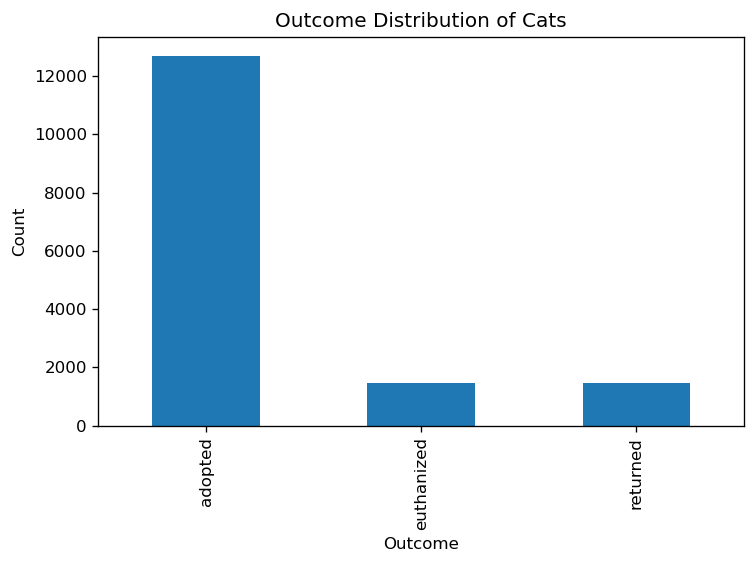

Saved: figures/outcome_distribution.png


In [24]:
#Analysis: EDA Figure 1
vc = df['outcome_simple'].value_counts().sort_values(ascending=False)

plt.figure()
vc.plot(kind='bar', title='Outcome Distribution of Cats')
plt.xlabel('Outcome'); plt.ylabel('Count'); plt.tight_layout()
plt.savefig('figures/outcome_distribution.png'); plt.show()
print('Saved: figures/outcome_distribution.png')

<Figure size 768x576 with 0 Axes>

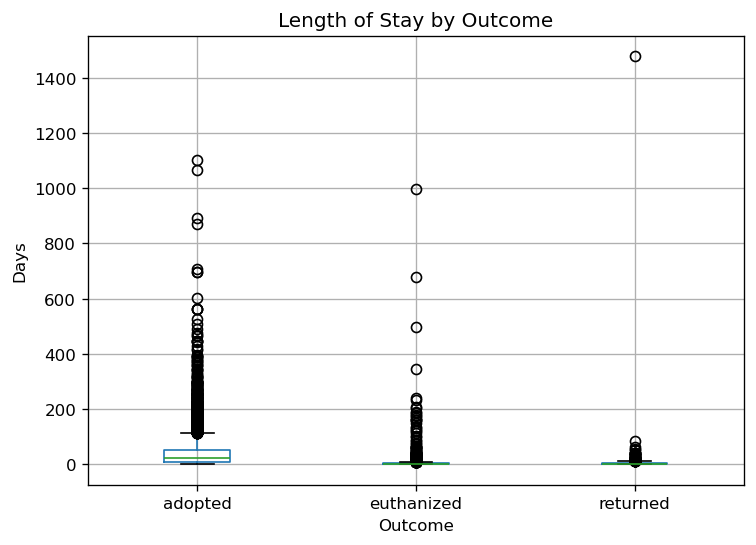

Saved: figures/los_by_outcome.png


In [9]:
#Analysis: EDA Figure 2
plt.figure()
df.boxplot(column='length_of_stay_days', by='outcome_simple')
plt.title('Length of Stay by Outcome'); plt.suptitle('')
plt.xlabel('Outcome'); plt.ylabel('Days'); plt.tight_layout()
plt.savefig('figures/los_by_outcome.png'); plt.show()
print('Saved: figures/los_by_outcome.png')

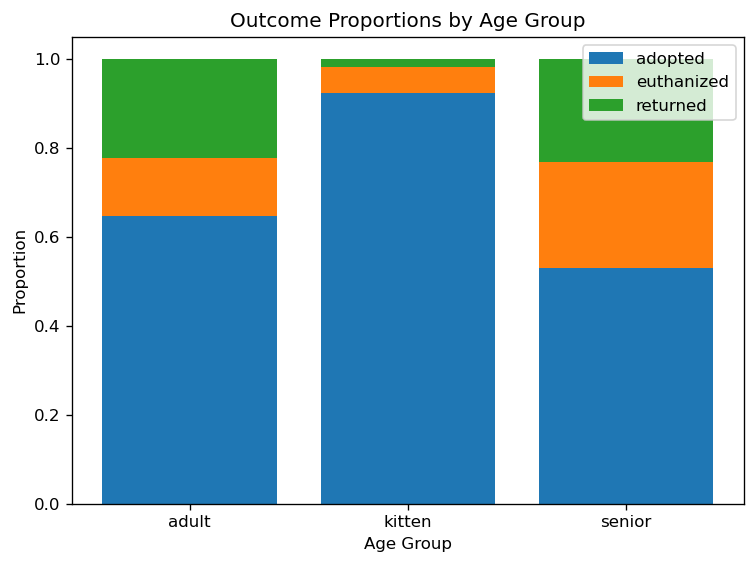

Saved: figures/agegroup_outcome_proportions.png


In [10]:
#Analysis: EDA Figure 3
ct = pd.crosstab(df['age_group'], df['outcome_simple'], normalize='index').fillna(0)

plt.figure()
bottom = np.zeros(len(ct))
for col in ct.columns:
    plt.bar(ct.index, ct[col], bottom=bottom, label=col)
    bottom += ct[col].values
plt.title('Outcome Proportions by Age Group')
plt.xlabel('Age Group'); plt.ylabel('Proportion'); plt.legend(); plt.tight_layout()
plt.savefig('figures/agegroup_outcome_proportions.png'); plt.show()
print('Saved: figures/agegroup_outcome_proportions.png')

In [11]:
#Model 1 — Multinomial Logistic Regression
# + Appropriate for a multi-class categorical outcome.
# + Interpretable coefficients.
# - Assumes linearity in the logit; interactions need to be added manually.

categorical_feats = [c for c in ['intake_type','intake_condition','breed','intake_altered','age_group'] if c in df.columns]
numeric_feats = [c for c in ['length_of_stay_days','age_upon_intake_days'] if c in df.columns]

X = df[categorical_feats + numeric_feats].copy()
y = df['outcome_simple'].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

prep_lr = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), categorical_feats),
                             ('num', 'passthrough', numeric_feats)])

log_reg = LogisticRegression(max_iter=250, multi_class='multinomial')
pipe_lr = Pipeline([('prep', prep_lr), ('clf', log_reg)])

pipe_lr.fit(X_train, y_train)
pred_lr = pipe_lr.predict(X_test)

acc_lr = accuracy_score(y_test, pred_lr)
f1_lr  = f1_score(y_test, pred_lr, average='macro')

print('Logistic Regression — Accuracy:', round(acc_lr, 3), '| Macro-F1:', round(f1_lr, 3))
print('\nClassification Report (LogReg):\n', classification_report(y_test, pred_lr, digits=3))

Logistic Regression — Accuracy: 0.893 | Macro-F1: 0.731

Classification Report (LogReg):
               precision    recall  f1-score   support

     adopted      0.924     0.972     0.948      2543
  euthanized      0.735     0.573     0.644       295
    returned      0.690     0.531     0.600       294

    accuracy                          0.893      3132
   macro avg      0.783     0.692     0.731      3132
weighted avg      0.884     0.893     0.886      3132



C:\Users\iseen\anaconda3\anaconda33\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [15]:
#Model 2 — Random Forest
# + Captures nonlinearities & interactions; usually stronger predictive performance.
# - Less directly interpretable; risk of overfitting without tuning.

prep_rf = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), categorical_feats),
                             ('num', 'passthrough', numeric_feats)])
rf = RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1)
pipe_rf = Pipeline([('prep', prep_rf), ('clf', rf)])

pipe_rf.fit(X_train, y_train)
pred_rf = pipe_rf.predict(X_test)

acc_rf = accuracy_score(y_test, pred_rf)
f1_rf  = f1_score(y_test, pred_rf, average='macro')

print('Random Forest — Accuracy:', round(acc_rf, 3), '| Macro-F1:', round(f1_rf, 3))
print('\nClassification Report (RF):\n', classification_report(y_test, pred_rf, digits=3))

Random Forest — Accuracy: 0.914 | Macro-F1: 0.783

Classification Report (RF):
               precision    recall  f1-score   support

     adopted      0.949     0.974     0.962      2543
  euthanized      0.781     0.739     0.760       295
    returned      0.694     0.571     0.627       294

    accuracy                          0.914      3132
   macro avg      0.808     0.762     0.783      3132
weighted avg      0.909     0.914     0.911      3132



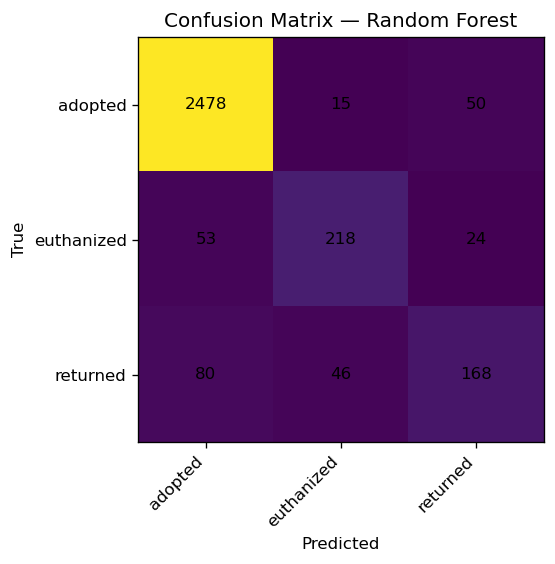

Saved: figures/cm_rf.png


In [16]:
#Confusion Matrix image (RF)
cm = confusion_matrix(y_test, pred_rf, labels=sorted(y.unique()))
fig, ax = plt.subplots()
im = ax.imshow(cm)
ax.set_title('Confusion Matrix — Random Forest')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
classes = sorted(y.unique())
ax.set_xticks(range(len(classes))); ax.set_xticklabels(classes, rotation=45, ha='right')
ax.set_yticks(range(len(classes))); ax.set_yticklabels(classes)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha='center', va='center')
fig.tight_layout(); fig.savefig('figures/cm_rf.png'); plt.show()
print('Saved: figures/cm_rf.png')

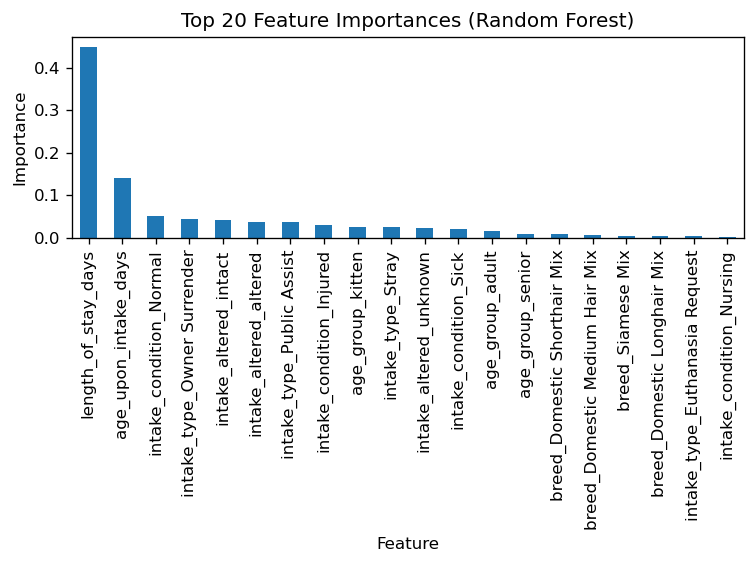

Saved: figures/rf_feature_importance_top20.png


In [17]:
#Feature Importance (top 20) + CSV
ohe = pipe_rf.named_steps['prep'].transformers_[0][1]
cat_cols = list(ohe.get_feature_names_out(categorical_feats)) if hasattr(ohe, 'get_feature_names_out') else []
final_cols = cat_cols + numeric_feats

importances = pipe_rf.named_steps['clf'].feature_importances_
fi = pd.Series(importances, index=final_cols).sort_values(ascending=False).head(20)

plt.figure()
fi.plot(kind='bar', title='Top 20 Feature Importances (Random Forest)')
plt.xlabel('Feature'); plt.ylabel('Importance'); plt.tight_layout()
plt.savefig('figures/rf_feature_importance_top20.png'); plt.show()
print('Saved: figures/rf_feature_importance_top20.png')
fi.to_csv('artifacts/rf_feature_importance_top20.csv')

In [18]:
#Macro ROC-AUC (OVR) for RF
try:
    proba_rf = pipe_rf.predict_proba(X_test)
    y_test_bin = pd.get_dummies(y_test).reindex(columns=pipe_rf.classes_, fill_value=0).values
    auc_macro = roc_auc_score(y_test_bin, proba_rf, average='macro', multi_class='ovr')
    print('Random Forest — Macro ROC-AUC (OVR):', round(auc_macro, 3))
except Exception as e:
    print('ROC-AUC not available:', e)

Random Forest — Macro ROC-AUC (OVR): 0.939


In [22]:
#Data Summary & Implications
summary = []
summary.append("RESULTS SUMMARY")
summary.append(
    f"- Models compared: LogReg (Acc={acc_lr:.3f}, F1={f1_lr:.3f}) | "
    f"RF (Acc={acc_rf:.3f}, F1={f1_rf:.3f})"
)
summary.append("- Key signals (RF importance): see figures/rf_feature_importance_top20.png and artifacts/rf_feature_importance_top20.csv.")
summary.append("- Outcome distribution & LOS patterns: see figures/outcome_distribution.png and figures/los_by_outcome.png.")
summary.append("Implications: target support for high-risk groups; optimize LOS pathways; expand foster-to-adopt.")
summary.append("Limitations: single-shelter data; observational design; LOS is outcome-aware.")
summary.append("Future work: external validation; causal designs; survival analysis for time-to-adoption.")

txt = "\n".join(summary)
print(txt)
with open('artifacts/task2_results_summary.txt','w') as f: f.write(txt)
print("Saved: artifacts/task2_results_summary.txt")

RESULTS SUMMARY
- Models compared: LogReg (Acc=0.893, F1=0.731) | RF (Acc=0.914, F1=0.783)
- Key signals (RF importance): see figures/rf_feature_importance_top20.png and artifacts/rf_feature_importance_top20.csv.
- Outcome distribution & LOS patterns: see figures/outcome_distribution.png and figures/los_by_outcome.png.
Implications: target support for high-risk groups; optimize LOS pathways; expand foster-to-adopt.
Limitations: single-shelter data; observational design; LOS is outcome-aware.
Future work: external validation; causal designs; survival analysis for time-to-adoption.
Saved: artifacts/task2_results_summary.txt
